In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/sem6/Student_performance_data _.csv')
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [ ]:
## we just checked if there are duplicate rows or not and also for missing values , basic things

#dataset shape
print("Dataset Shape (Rows, Columns):")
print(df.shape)

print("\nColumns in Dataset:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("Unique values for grade class")
print(df['GradeClass'].unique())

Dataset Shape (Rows, Columns):
(2392, 15)

Columns in Dataset:
Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

Data Types:
StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

Missing Values:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0

In [ ]:
##data preprocessing

#dropping unneccesary columns
df2 = df.drop(columns =["StudentID"])
df2.head()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [ ]:
##EDA - exploratory data analysis

print("statistical summary")
print(df2.describe())

statistical summary
               Age       Gender    Ethnicity  ParentalEducation  \
count  2392.000000  2392.000000  2392.000000        2392.000000   
mean     16.468645     0.510870     0.877508           1.746237   
std       1.123798     0.499986     1.028476           1.000411   
min      15.000000     0.000000     0.000000           0.000000   
25%      15.000000     0.000000     0.000000           1.000000   
50%      16.000000     1.000000     0.000000           2.000000   
75%      17.000000     1.000000     2.000000           2.000000   
max      18.000000     1.000000     3.000000           4.000000   

       StudyTimeWeekly     Absences     Tutoring  ParentalSupport  \
count      2392.000000  2392.000000  2392.000000      2392.000000   
mean          9.771992    14.541388     0.301421         2.122074   
std           5.652774     8.467417     0.458971         1.122813   
min           0.001057     0.000000     0.000000         0.000000   
25%           5.043079     7.00

correlation between data
                        Age    Gender  Ethnicity  ParentalEducation  \
Age                1.000000  0.044895  -0.028473           0.025099   
Gender             0.044895  1.000000   0.016010           0.006771   
Ethnicity         -0.028473  0.016010   1.000000           0.033595   
ParentalEducation  0.025099  0.006771   0.033595           1.000000   
StudyTimeWeekly   -0.006800  0.011469   0.007184          -0.011051   
Absences          -0.011511  0.021479  -0.025712           0.036518   
Tutoring          -0.012076 -0.031597  -0.017440          -0.017340   
ParentalSupport    0.033197  0.008065   0.020922          -0.017463   
Extracurricular   -0.025061 -0.005964  -0.008927           0.007479   
Sports            -0.046320 -0.008897  -0.004484           0.002029   
Music             -0.003492  0.007109  -0.014627           0.039439   
Volunteering       0.013074 -0.000200   0.013468           0.011960   
GPA                0.000275 -0.013360   0.027760    

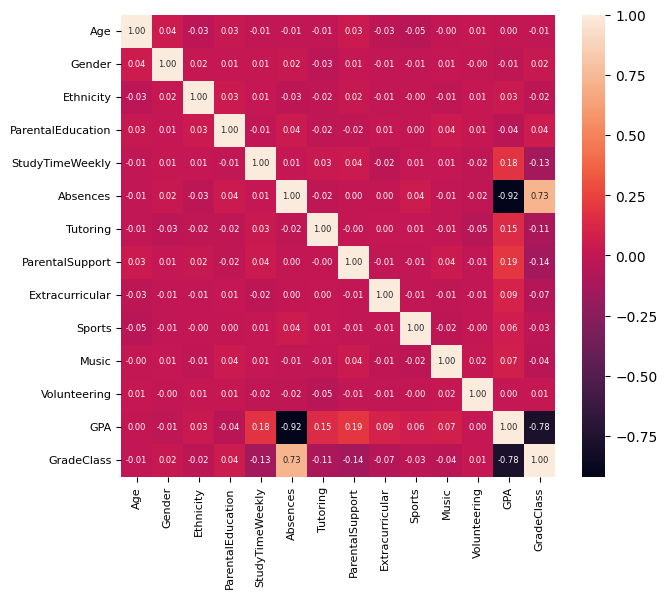

In [ ]:
##correlation

corr = df2.corr()
print("correlation between data")
print(corr)

plt.figure(figsize=(7, 6))
plt.xticks(fontsize=8)   # reduce column name size
plt.yticks(fontsize=8)
sns.heatmap(corr, annot=True,annot_kws={"fontsize": 6},fmt=".2f")
plt.show()

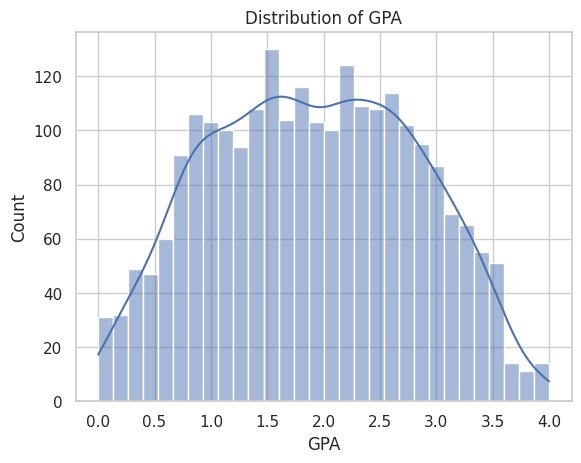

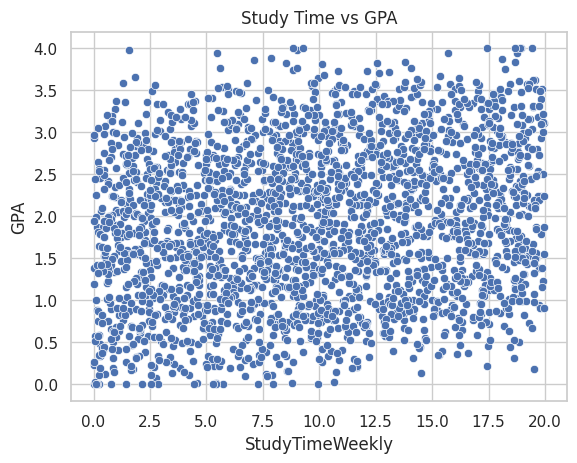

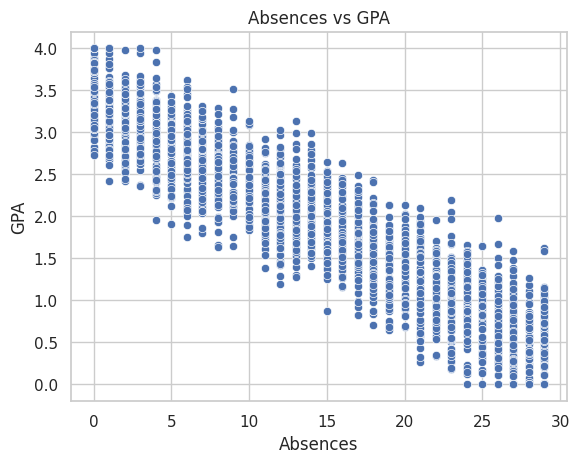

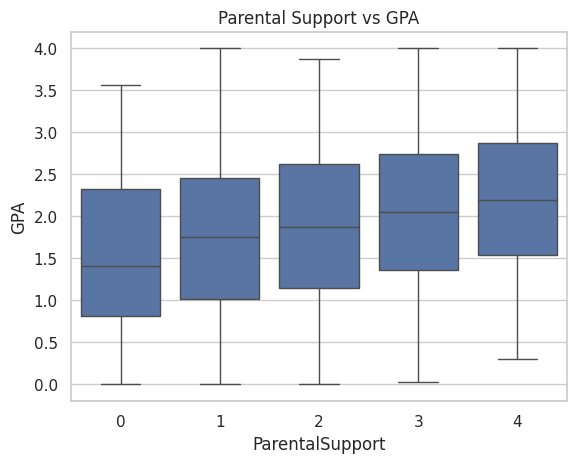

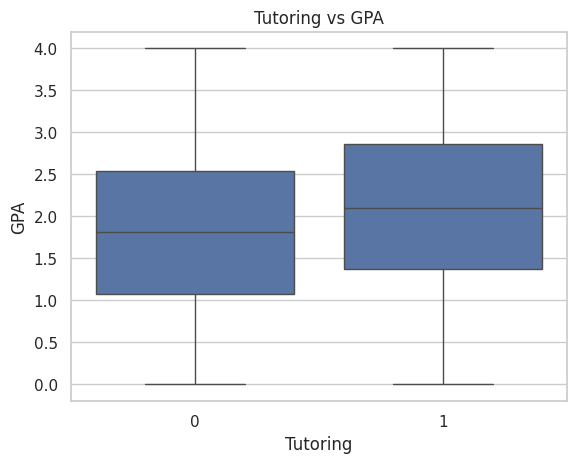

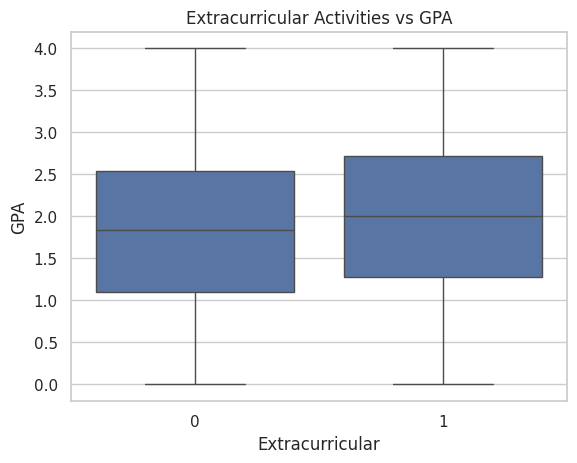

<function matplotlib.pyplot.show(close=None, block=None)>

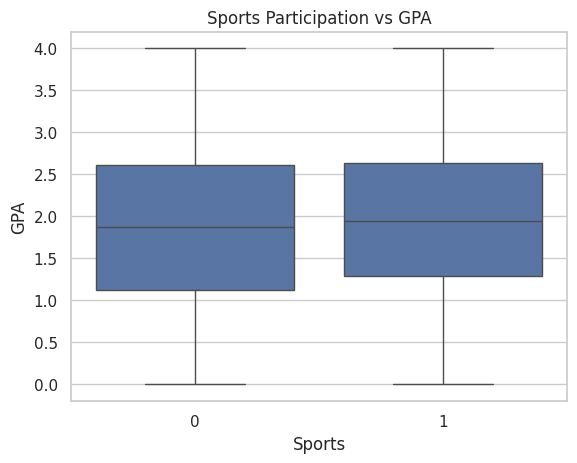

In [ ]:
## graphs for understanding EDA

sns.set(style="whitegrid")

sns.histplot(df['GPA'], bins=30, kde=True)
plt.title("Distribution of GPA")
plt.show()

sns.scatterplot(x='StudyTimeWeekly', y='GPA', data=df2)
plt.title("Study Time vs GPA")
plt.show()

sns.scatterplot(x='Absences', y='GPA', data=df2)
plt.title("Absences vs GPA")
plt.show()

sns.boxplot(x='ParentalSupport', y='GPA', data=df2)
plt.title("Parental Support vs GPA")
plt.show()

sns.boxplot(x='Tutoring', y='GPA', data=df2)
plt.title("Tutoring vs GPA")
plt.show()

sns.boxplot(x='Extracurricular', y='GPA', data=df)
plt.title("Extracurricular Activities vs GPA")
plt.show()

sns.boxplot(x='Sports', y='GPA', data=df)
plt.title("Sports Participation vs GPA")
plt.show

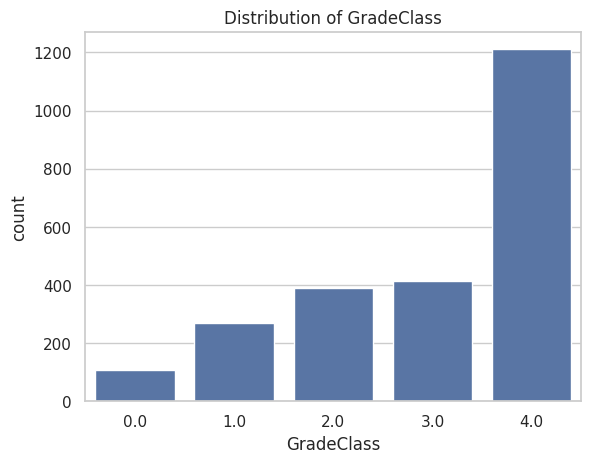

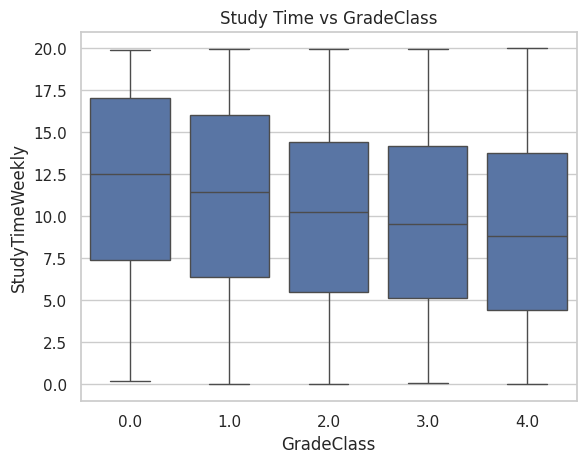

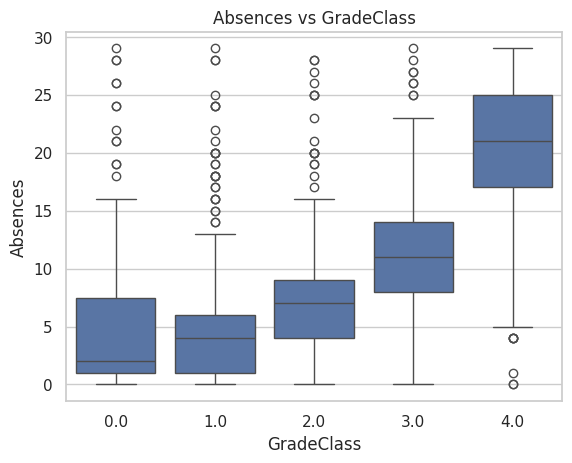

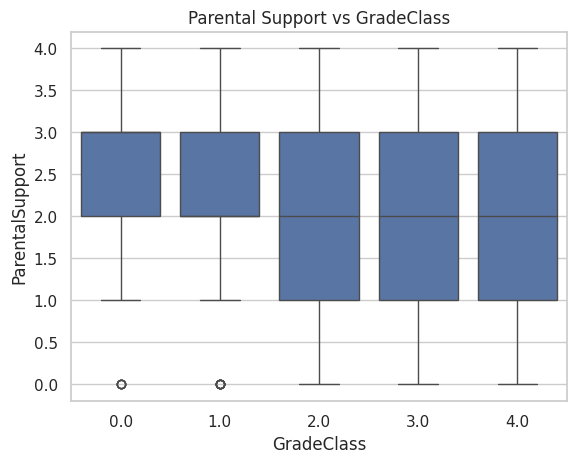

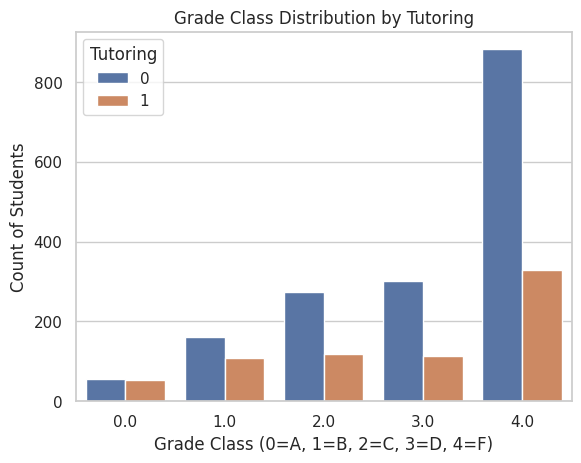

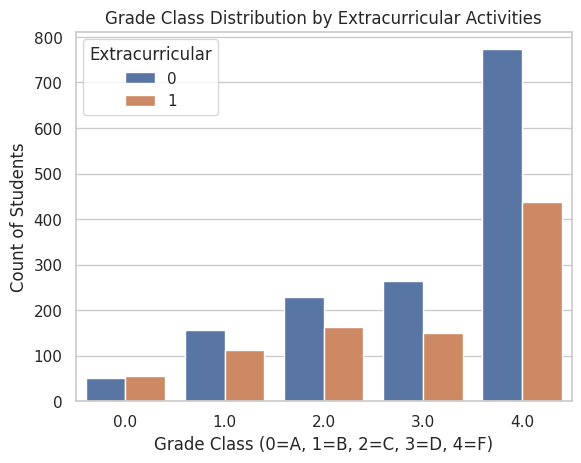

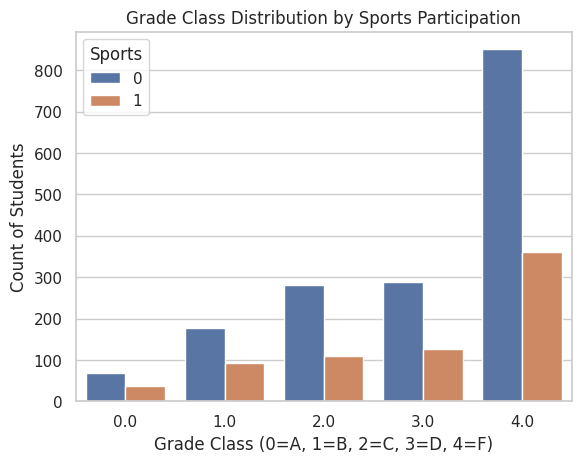

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# graphs for understanding EDA of GradeClass

sns.set(style="whitegrid")

# GradeClass distribution
sns.countplot(x='GradeClass', data=df2)
plt.title("Distribution of GradeClass")
plt.show()


# Study Time vs GradeClass
sns.boxplot(x='GradeClass', y='StudyTimeWeekly', data=df2)
plt.title("Study Time vs GradeClass")
plt.show()


# Absences vs GradeClass
sns.boxplot(x='GradeClass', y='Absences', data=df2)
plt.title("Absences vs GradeClass")
plt.show()


# Parental Support vs GradeClass
sns.boxplot(x='GradeClass', y='ParentalSupport', data=df2)
plt.title("Parental Support vs GradeClass")
plt.show()


sns.countplot(x='GradeClass', hue='Tutoring', data=df2)
plt.title("Grade Class Distribution by Tutoring")
plt.xlabel("Grade Class (0=A, 1=B, 2=C, 3=D, 4=F)")
plt.ylabel("Count of Students")
plt.show()

sns.countplot(x='GradeClass', hue='Extracurricular', data=df2)
plt.title("Grade Class Distribution by Extracurricular Activities")
plt.xlabel("Grade Class (0=A, 1=B, 2=C, 3=D, 4=F)")
plt.ylabel("Count of Students")
plt.show()

sns.countplot(x='GradeClass', hue='Sports', data=df2)
plt.title("Grade Class Distribution by Sports Participation")
plt.xlabel("Grade Class (0=A, 1=B, 2=C, 3=D, 4=F)")
plt.ylabel("Count of Students")
plt.show()

In [ ]:
##train_test_split
df2.head()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [ ]:
df2.groupby('GradeClass')['GPA'].describe()

,count,mean,std,min,25%,50%,75%,max
GradeClass,,,,,,,,
0.0,107.0,3.102942,0.946137,0.214570,2.562795,3.548460,3.694455,4.000000
1.0,269.0,3.001673,0.630402,0.000000,3.055254,3.167455,3.332789,3.572945
2.0,391.0,2.659742,0.378969,0.557549,2.590990,2.712230,2.851936,3.597766
3.0,414.0,2.215545,0.361295,0.000000,2.122740,2.238196,2.377751,4.000000
4.0,1211.0,1.208041,0.547875,0.000000,0.816809,1.247482,1.626695,3.979421


In [ ]:
#train_test_split
X = df2.drop(columns=['GPA','GradeClass'])
y = df2['GPA']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)
print(X_test)
print(y_train)
print(y_test)

      Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  \
642    18       1          0                  4        18.118879        24   
1752   16       1          3                  2         2.469271        19   
1401   17       0          2                  3         3.456401        25   
2032   17       1          0                  1        15.838131        25   
990    16       0          0                  0         1.045373        19   
...   ...     ...        ...                ...              ...       ...   
1638   15       0          1                  0        13.092424        13   
1095   16       0          0                  2         2.159249        19   
1130   16       1          0                  2         3.572578        14   
1294   18       0          3                  2         4.402585        20   
860    18       0          1                  2         5.427628        27   

      Tutoring  ParentalSupport  Extracurricular  Sports  Music

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,root_mean_squared_error

# Calculate evaluation metrics

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)
print("RMSE:", rmse)

MSE: 0.03866144149454257
MAE: 0.15529483485748097
R2 Score: 0.9532471681022928
RMSE: 0.19662512935670906


In [ ]:
#training data error
y_train_pred = model.predict(X_train_scaled)

mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)

print("Training Data:")
print("MSE:", mse_train)
print("MAE:", mae_train)
print("R2 Score:", r2_train)
print("RMSE:", rmse_train)

Training Data:
MSE: 0.038497064610156735
MAE: 0.15918013522226315
R2 Score: 0.9541479286300485
RMSE: 0.1962066884949561


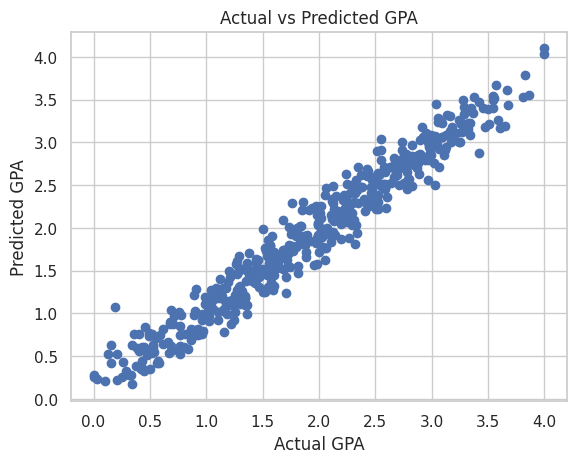

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA")
plt.show()

In [ ]:
new_student = np.array([[18, 1, 2, 4, 10.456, 0, 1, 0, 1, 1, 1, 1]])
new_student_scaled = scaler.transform(new_student)

predicted_gpa = model.predict(new_student_scaled)
print("Predicted GPA for the new student:", predicted_gpa[0])

Predicted GPA for the new student: 3.606038519252732


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


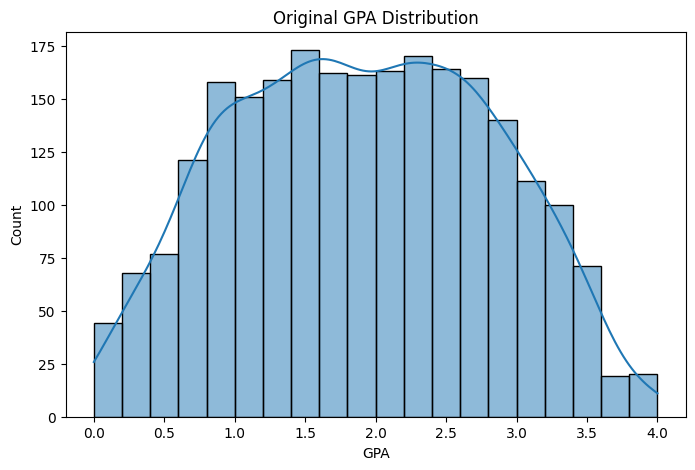

GPA Category Counts:
GPA_Category
Low       1274
Medium     797
High       321
Name: count, dtype: int64


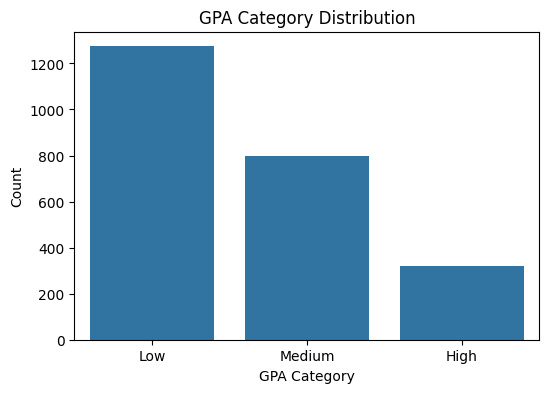


Sample Weights Assigned:
        GPA GPA_Category  sample_weight
0  2.929196       Medium       1.000418
1  3.042915         High       2.483904
2  0.112602          Low       0.625850
3  2.054218       Medium       1.000418
4  1.288061          Low       0.625850
5  3.084184         High       2.483904
6  2.748237       Medium       1.000418
7  1.360143          Low       0.625850
8  2.896819       Medium       1.000418
9  3.573474         High       2.483904

Average Weight per GPA Category:
GPA_Category
Low       0.625850
Medium    1.000418
High      2.483904
Name: sample_weight, dtype: float64

Balanced dataset saved as 'student_performance_balanced.csv'


/tmp/ipykernel_44024/2320823756.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('GPA_Category')['sample_weight'].mean())


In [ ]:
# Load dataset

df = pd.read_csv("/content/drive/MyDrive/sem6/student_performance_balanced.csv")
df = df.drop(columns =["StudentID"])
# ===============================
# STEP 1: Check GPA Distribution
# ===============================
plt.figure(figsize=(8,5))
sns.histplot(df['GPA'], bins=20, kde=True)
plt.title("Original GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Count")
plt.show()

# ===============================
# STEP 2: Create GPA Categories
# ===============================
# Low: GPA < 2.0
# Medium: 2.0 <= GPA < 3.0
# High: GPA >= 3.0

bins = [0, 2.0, 3.0, 4.0]
labels = ['Low', 'Medium', 'High']

df['GPA_Category'] = pd.cut(df['GPA'], bins=bins, labels=labels, include_lowest=True)

# Show counts
print("GPA Category Counts:")
print(df['GPA_Category'].value_counts())

# Plot category distribution
plt.figure(figsize=(6,4))
sns.countplot(x='GPA_Category', data=df)
plt.title("GPA Category Distribution")
plt.xlabel("GPA Category")
plt.ylabel("Count")
plt.show()

# ===============================
# STEP 3: Calculate Sample Weights
# ===============================
# Inverse frequency weighting
category_counts = df['GPA_Category'].value_counts().to_dict()

df['sample_weight'] = df['GPA_Category'].map(lambda x: 1 / category_counts[x])


# Normalize weights so average weight = 1
df['sample_weight'] = pd.to_numeric(df['sample_weight'], errors='coerce')
df['sample_weight'] = df['sample_weight'] / df['sample_weight'].mean()

# ===============================
# STEP 4: Check Balanced Weights
# ===============================
print("\nSample Weights Assigned:")
print(df[['GPA', 'GPA_Category', 'sample_weight']].head(10))

# Average weight per category
print("\nAverage Weight per GPA Category:")
print(df.groupby('GPA_Category')['sample_weight'].mean())

# ===============================
# STEP 5: Save Balanced Dataset
# ===============================
df.to_csv("student_performance_balanced.csv", index=False)

print("\nBalanced dataset saved as 'student_performance_balanced.csv'")

In [ ]:
df.head()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,GPA_Category,sample_weight
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0,Medium,1.000418
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0,High,2.483904
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0,Low,0.625850
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0,Medium,1.000418
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0,Low,0.625850


Dataset Shape: (2392, 16)

Columns:
 Index(['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly',
       'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports',
       'Music', 'Volunteering', 'GPA', 'GradeClass', 'GPA_Category',
       'sample_weight'],
      dtype='object')

Feature Columns Used:
['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

Numerical Columns: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']
Categorical Columns: []

Train Shape: (1913, 12)
Test Shape: (479, 12)

===== Linear Regression Results =====
MAE : 0.15601482975636813
MSE : 0.03916558924432515
RMSE: 0.19790297937202753
R² Score: 0.9526375080874039


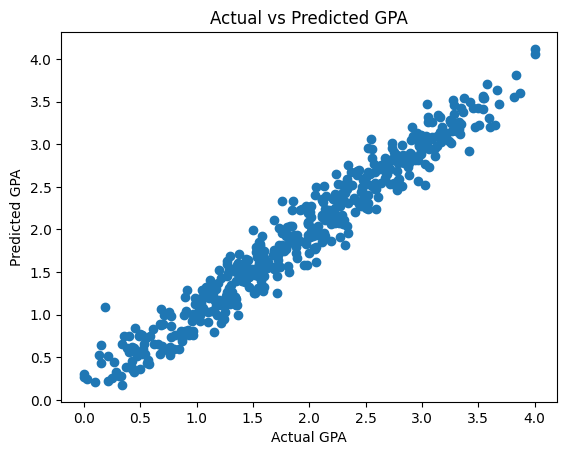


===== Random Forest Regressor Results =====
MAE : 0.18759808123785646
MSE : 0.05841268733547012
RMSE: 0.24168716833019938
R² Score: 0.9293622160447881


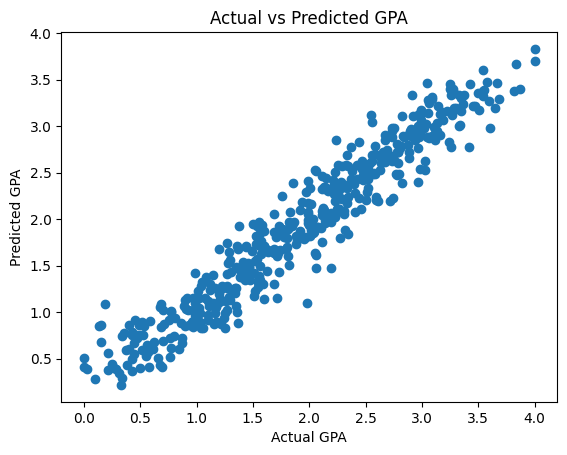


===== Model Comparison =====
                     Model       MAE       MSE      RMSE  R2 Score
0        Linear Regression  0.156015  0.039166  0.197903  0.952638
1  Random Forest Regressor  0.187598  0.058413  0.241687  0.929362


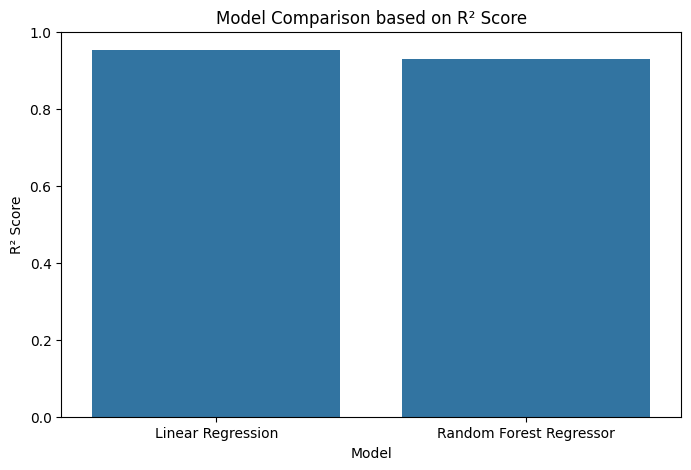

In [ ]:
# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# STEP 2: LOAD BALANCED DATASET
# ==========================================
df = pd.read_csv("/content/student_performance_balanced.csv")   # or your saved path

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

# ==========================================
# STEP 3: DEFINE FEATURES AND TARGET
# ==========================================
# Target = GPA
y = df['GPA']

# Remove unnecessary columns
X = df.drop(columns=['StudentID', 'GPA', 'GradeClass', 'GPA_Category', 'sample_weight'], errors='ignore')

# Sample weights
sample_weights = df['sample_weight']

print("\nFeature Columns Used:")
print(X.columns.tolist())

# ==========================================
# STEP 4: IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ==========================================
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("\nNumerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

# ==========================================
# STEP 5: PREPROCESSING
# ==========================================
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# ==========================================
# STEP 6: TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, sample_weights, test_size=0.2, random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ==========================================
# STEP 7: LINEAR REGRESSION MODEL
# ==========================================
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train, model__sample_weight=w_train)

y_pred_lr = linear_model.predict(X_test)

# Metrics for Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n===== Linear Regression Results =====")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)


plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA")
plt.show()


# ==========================================
# STEP 8: RANDOM FOREST REGRESSOR MODEL
# ==========================================
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train, model__sample_weight=w_train)

y_pred_rf = rf_model.predict(X_test)

# Metrics for Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n===== Random Forest Regressor Results =====")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA")
plt.show()


# ==========================================
# STEP 9: COMPARE BOTH MODELS
# ==========================================
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [mae_lr, mae_rf],
    'MSE': [mse_lr, mse_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

print("\n===== Model Comparison =====")
print(results)

# ==========================================
# STEP 10: BAR CHART FOR COMPARISON
# ==========================================
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='R2 Score', data=results)
plt.title("Model Comparison based on R² Score")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.show()

Balanced Dataset Columns:
Index(['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly',
       'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports',
       'Music', 'Volunteering', 'GPA', 'GradeClass', 'GPA_Category',
       'sample_weight'],
      dtype='object')

First 5 Rows of Balanced Dataset:
   Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  \
0   17       1          0                  2        19.833723         7   
1   18       0          0                  1        15.408756         0   
2   15       0          2                  3         4.210570        26   
3   17       1          0                  3        10.028829        14   
4   17       1          0                  2         4.672495        17   

   Tutoring  ParentalSupport  Extracurricular  Sports  Music  Volunteering  \
0         1                2                0       0      1             0   
1         0                1                0       0      0

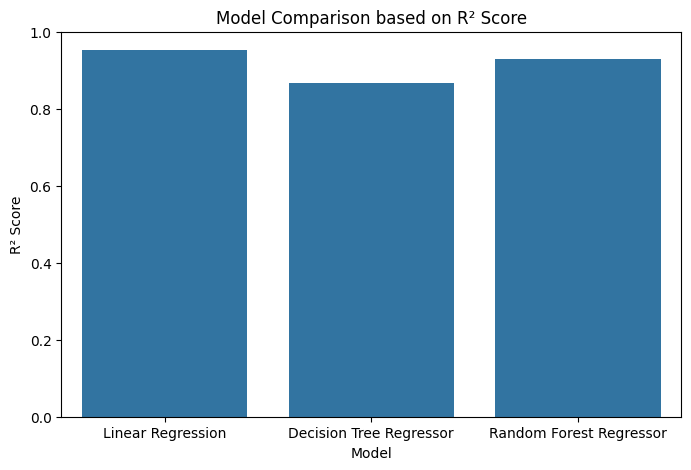

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd


# ==========================================
# CHECK BALANCED DATASET COLUMNS
# ==========================================
print("Balanced Dataset Columns:")
print(df.columns)

print("\nFirst 5 Rows of Balanced Dataset:")
print(df.head())

# ==========================================
# DECISION TREE REGRESSOR MODEL
# ==========================================
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ))
])

# Train model using balanced sample weights
dt_model.fit(X_train, y_train, model__sample_weight=w_train)

# Predict on test data
y_pred_dt = dt_model.predict(X_test)

# ==========================================
# EVALUATION METRICS
# ==========================================
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\n===== Decision Tree Regressor Results =====")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R² Score:", r2_dt)

# ==========================================
# UPDATED MODEL COMPARISON TABLE
# ==========================================
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor'],
    'MAE': [mae_lr, mae_dt, mae_rf],
    'MSE': [mse_lr, mse_dt, mse_rf],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf],
    'R2 Score': [r2_lr, r2_dt, r2_rf]
})

print("\n===== Updated Model Comparison =====")
print(results)


plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='R2 Score', data=results)
plt.title("Model Comparison based on R² Score")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ==========================================
# RANDOM FOREST REGRESSOR MODEL
# ==========================================
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,     # number of trees
        max_depth=12,         # control overfitting
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1             # use all CPU cores
    ))
])

# Train model using balanced sample weights
rf_model.fit(X_train, y_train, model__sample_weight=w_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# ==========================================
# EVALUATION METRICS
# ==========================================
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n===== Random Forest Regressor Results =====")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)


===== Random Forest Regressor Results =====
MAE : 0.18736726982310983
MSE : 0.05807584113155264
RMSE: 0.24098929671575176
R² Score: 0.9297695602445474
